In [98]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

In [99]:
from lobster import *

In [100]:
ticker = "GOOG"
message_path  = f"data/LOBSTER_SampleFile_{ticker}_2012-06-21_5/{ticker}_2012-06-21_34200000_57600000_message_5.csv"
orderbook_path = f"data/LOBSTER_SampleFile_{ticker}_2012-06-21_5/{ticker}_2012-06-21_34200000_57600000_orderbook_5.csv"
levels=5
K=5

msg, ob, qr, df = load_lobster_data(message_path, orderbook_path, levels=levels, K=K)
#[["type", "lvl", "size", "P_1", "Q_1", "P_-1", "Q_-1", "P_2", "Q_2", "P_-2", "Q_-2", "P_3", "Q_3", "P_-3", "Q_-3", "P_4", "Q_4", "P_-4", "Q_-4", "P_5", "Q_5", "P_-5", "Q_-5"]]
df

,time,dtk,dtk_l,type,price,lvl,size,pref,P_1,Q_1,...,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5,seg_id
0,34200.059902,0.059902,0.059902,M,5794000,-1,300,5798150.0,5798200.0,0,...,0,5798500.0,0,5797800.0,0,5798600.0,0,5797700.0,0,1
1,34200.113247,0.053345,0.053345,M,5795100,-1,1,5798150.0,5798200.0,0,...,0,5798500.0,0,5797800.0,0,5798600.0,0,5797700.0,0,1
2,34200.113247,0.000000,0.000000,M,5795000,-1,1,5798150.0,5798200.0,0,...,0,5798500.0,0,5797800.0,0,5798600.0,0,5797700.0,0,1
3,34200.113247,0.000000,0.000000,M,5794900,-1,1,5798150.0,5798200.0,0,...,0,5798500.0,0,5797800.0,0,5798600.0,0,5797700.0,0,1
4,34200.113247,0.000000,0.000000,M,5794800,-1,1,5798150.0,5798200.0,0,...,0,5798500.0,0,5797800.0,0,5798600.0,0,5797700.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14289,57598.335694,0.122506,0.000000,M,5652100,-1,75,5653450.0,5653500.0,0,...,0,5653800.0,0,5653100.0,0,5653900.0,0,5653000.0,0,6038
14290,57598.675338,0.339644,0.339644,M,5653000,-1,188,5653450.0,5653500.0,0,...,0,5653800.0,0,5653100.0,0,5653900.0,0,5653000.0,0,6038
14291,57598.819072,0.143734,0.143734,M,5652400,-1,200,5653450.0,5653500.0,0,...,0,5653800.0,0,5653100.0,0,5653900.0,0,5653000.0,0,6038
14292,57598.957742,0.138670,0.138670,M,5653500,-1,100,5653450.0,5653500.0,0,...,0,5653800.0,0,5653100.0,0,5653900.0,0,5653000.0,0,6038


In [101]:
table1 = make_descriptive_table(df, K=5)
table1

,#L (×10^3),#C (×10^3),#M (×10^2),AES,AIT (ms)
Level,,,,,
1,0.17,0.11,116.77,62.38,338.9
2,0.20,0.15,0.00,105.65,202.5
3,0.32,0.22,0.00,103.03,264.1
4,0.40,0.23,0.00,91.54,316.8
5,0.55,0.28,0.00,97.39,407.7


In [102]:
aes = compute_aes_by_level(df, K=5, lvl_col="lvl", size_col="size") 
df_norm = normalize_by_aes(df, aes=aes, K=5)
df_norm.head(10)

,time,dtk,dtk_l,type,price,lvl,size,pref,P_1,Q_1,...,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5,seg_id
0,34200.059902,0.059902,0.059902,M,5794000,-1,5,5798150.0,5798200.0,0,...,0,5798500.0,0,5797800.0,0,5798600.0,0,5797700.0,0,1
1,34200.113247,0.053345,0.053345,M,5795100,-1,1,5798150.0,5798200.0,0,...,0,5798500.0,0,5797800.0,0,5798600.0,0,5797700.0,0,1
2,34200.113247,0.000000,0.000000,M,5795000,-1,1,5798150.0,5798200.0,0,...,0,5798500.0,0,5797800.0,0,5798600.0,0,5797700.0,0,1
3,34200.113247,0.000000,0.000000,M,5794900,-1,1,5798150.0,5798200.0,0,...,0,5798500.0,0,5797800.0,0,5798600.0,0,5797700.0,0,1
4,34200.113247,0.000000,0.000000,M,5794800,-1,1,5798150.0,5798200.0,0,...,0,5798500.0,0,5797800.0,0,5798600.0,0,5797700.0,0,1
5,34200.113247,0.000000,0.000000,M,5794000,-1,3,5798150.0,5798200.0,0,...,0,5798500.0,0,5797800.0,0,5798600.0,0,5797700.0,0,1
6,34200.203135,0.089889,0.000000,M,5794000,-1,1,5796450.0,5796500.0,0,...,0,5796800.0,0,5796100.0,0,5796900.0,0,5796000.0,0,2
7,34200.203135,0.000000,0.000000,M,5794000,-1,2,5795050.0,5795100.0,0,...,0,5795400.0,0,5794700.0,0,5795500.0,0,5794600.0,0,3
8,34200.207763,0.004628,0.004628,M,5794000,1,1,5795050.0,5795100.0,0,...,0,5795400.0,0,5794700.0,0,5795500.0,0,5794600.0,0,3
9,34200.236450,0.028687,0.000000,M,5794000,-1,1,5796450.0,5796500.0,0,...,0,5796800.0,0,5796100.0,0,5796900.0,0,5796000.0,0,4


### Training DataFrame: ###
From where we will extract our different state vectors $x_k$.

In [103]:
df_train = df_norm.copy()

# 1) event id
event_map = {"L": 0, "C": 1, "M": 2}
df_train["event_id"] = df_train["type"].map(event_map).astype("int64")

# 2) hour
df_train["hour"] = (df_train["time"] // 3600).astype("int64")
hour_map = {h: i for i, h in enumerate(sorted(df_train["hour"].unique()))}
df_train["hour_id"] = df_train["hour"].map(hour_map).astype("int64")

# 3) last event id
df_train["last_event_id"] = df_train["event_id"].shift(1).fillna(0).astype("int64")

# 4) pre-event queues within each constant-pref segment
def _q_event_row(row):
    idx = row.name
    if idx == 0:
        return np.nan 
    prev = df_train.iloc[idx - 1]  # previous row
    l = int(row["lvl"])
    if l == 0:
        return np.nan
    return prev[f"Q_{l}"]
df_train["q_event"] = df_train.apply(_q_event_row, axis=1).astype("float64")

# 5) clean dataframe of nan
df_train = df_train.dropna().reset_index(drop=True)

# 5) keep only what you need
df_train = df_train[["q_event", "hour", "hour_id", "last_event_id", "event_id", "lvl", "dtk_l"]].copy()
df_train

,q_event,hour,hour_id,last_event_id,event_id,lvl,dtk_l
0,0.0,9,0,2,2,-1,0.053345
1,0.0,9,0,2,2,-1,0.000000
2,0.0,9,0,2,2,-1,0.000000
3,0.0,9,0,2,2,-1,0.000000
4,0.0,9,0,2,2,-1,0.000000
...,...,...,...,...,...,...,...
14288,0.0,15,6,2,2,-1,0.000000
14289,0.0,15,6,2,2,-1,0.339644
14290,0.0,15,6,2,2,-1,0.143734
14291,0.0,15,6,2,2,-1,0.138670


### QR Model Intensities ###

In [104]:
from qrFunctions import shift_orderbook_before_event, build_all_sequences, estimate_all_qr
df_qr = shift_orderbook_before_event(df_norm, K=5)
df_qr = df_qr.dropna().reset_index(drop=True)
seqs = build_all_sequences(df_qr, K=5)
lambdas, Ns, Ts = estimate_all_qr(seqs)

In [105]:
from qrFunctions import qr_transition_matrix
qr_matrix = qr_transition_matrix(Ns, K=K)
qr_matrix

,cancel,limit,trade
cancel,0.068705,0.114392,0.816903
limit,0.068705,0.114392,0.816903
trade,0.068705,0.114392,0.816903


### Training / Target vectors: ###

Vanilla : $x_k = [q_k]$

Hours: $x_k = [q_k, h_k]$

Last Event: $x_k = [q_k, \eta_{k-1}]$

Hours + Last Event: $x_k = [q_k, h_k, \eta_{k-1}]$

In [106]:
from dqrfunctions import build_dataset

data_vanilla = build_dataset(df_train, use_hour=False, use_last_event=False)
data_hour = build_dataset(df_train, use_hour=True, use_last_event=False)
data_last_event = build_dataset(df_train, use_hour=False, use_last_event=True)
data_hour_last_event = build_dataset(df_train, use_hour=True, use_last_event=True)

display(data_hour_last_event)

{'q': tensor([0., 0., 0.,  ..., 0., 0., 0.]),
 'y': tensor([2, 2, 2,  ..., 2, 2, 0]),
 'dt': tensor([0.0533, 0.0000, 0.0000,  ..., 0.1437, 0.1387, 0.0000]),
 'last_event': tensor([2, 2, 2,  ..., 2, 2, 2]),
 'hour_id': tensor([0, 0, 0,  ..., 6, 6, 6])}

### Neural Network Definition ###

In [107]:
from dqrfunctions import DQRNet

### Negative Log Likelihood ###

$\text{loss}\left(\theta | \epsilon\right) = l\left(\lambda_\theta | \epsilon\right) = \sum_{i=1}^{B} \left( \Lambda_\theta(x_k)\Delta t_k - \log{\lambda_\theta^{\eta_k}(x_k)} \right)$

In [108]:
from dqrfunctions import dqr_loss

### Training Loop ###

In [109]:
from dqrfunctions import train_model, get_or_train_model

### Vanilla Model ###

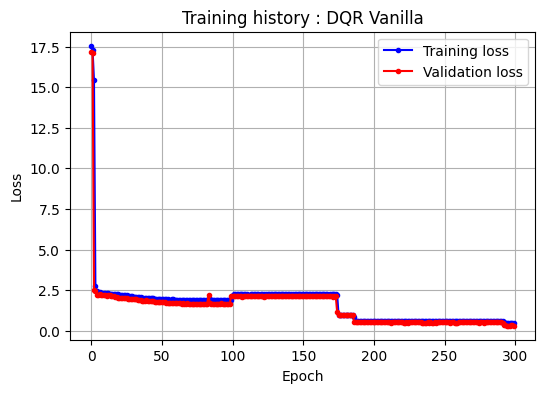

In [110]:
model_vanilla = get_or_train_model(
    f"models/{ticker}/dqr_vanilla.pt",
    data=data_vanilla,
    compute_model=False,
    use_hour=False,
    use_last_event=False)
model_vanilla.plot_history(model_name="Vanilla")

### Hour Model ###

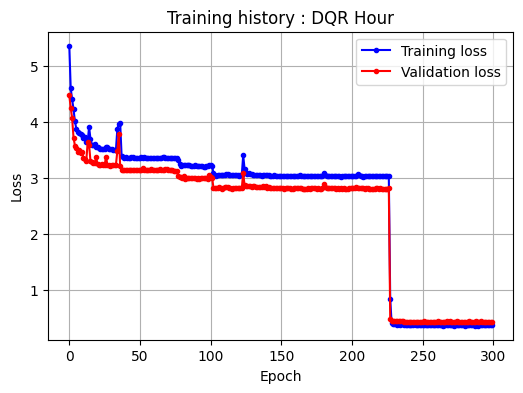

In [111]:
model_hour = get_or_train_model(
    f"models/{ticker}/dqr_hour.pt",
    data=data_hour,
    compute_model=False,
    use_hour=True,
    use_last_event=False,
    hour_num_classes=df_train["hour_id"].nunique())
model_hour.plot_history(model_name="Hour")

### Last-Event Model ###

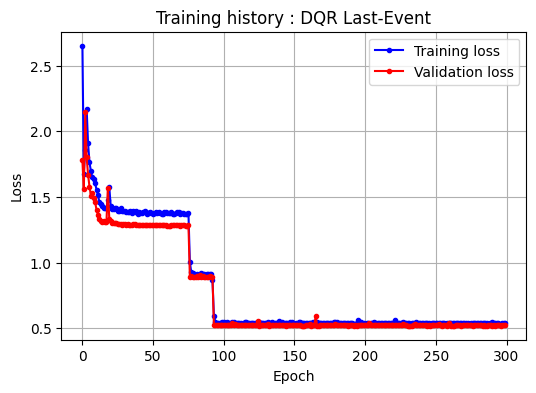

In [112]:
model_last_event = get_or_train_model(
    f"models/{ticker}/dqr_last_event.pt",
    data=data_last_event,
    compute_model=False,
    use_hour=False,
    use_last_event=True)
model_last_event.plot_history(model_name="Last-Event")

### Hour + Last-Event Model ###

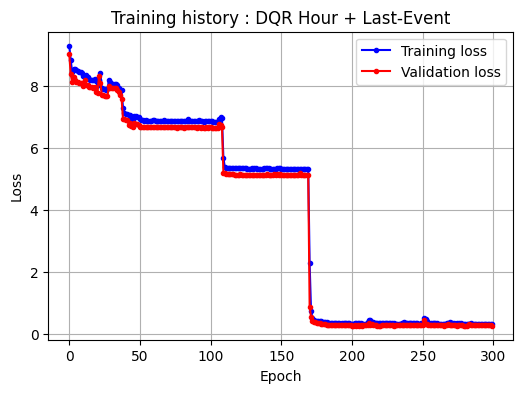

In [113]:
model_hour_last_event = get_or_train_model(
    f"models/{ticker}/dqr_hour_last_event.pt",
    data=data_hour_last_event,
    compute_model=False,
    use_hour=True,
    use_last_event=True,
    hour_num_classes=df_train["hour_id"].nunique())
model_hour_last_event.plot_history(model_name="Hour + Last-Event")

In [114]:
from dqrfunctions import transition_real, transition_dqr

event_id_np = df_train["event_id"].to_numpy()
last_id_np  = df_train["last_event_id"].to_numpy()
# DQR: last_event_id must match X lines format (torch)
last_id_t = torch.tensor(last_id_np, dtype=torch.long)

T_real = transition_real(event_id_np, last_id_np, n_events=3)
T_dqr_le = transition_dqr(
                        model=model_last_event,
                        data=data_last_event,
                        last_event_id=last_id_t,
                        n_events=3)
T_dqr_h_le = transition_dqr(
                        model=model_hour_last_event,
                        data=data_hour_last_event,
                        last_event_id=last_id_t,
                        n_events=3)
T_qr = qr_matrix.to_numpy()

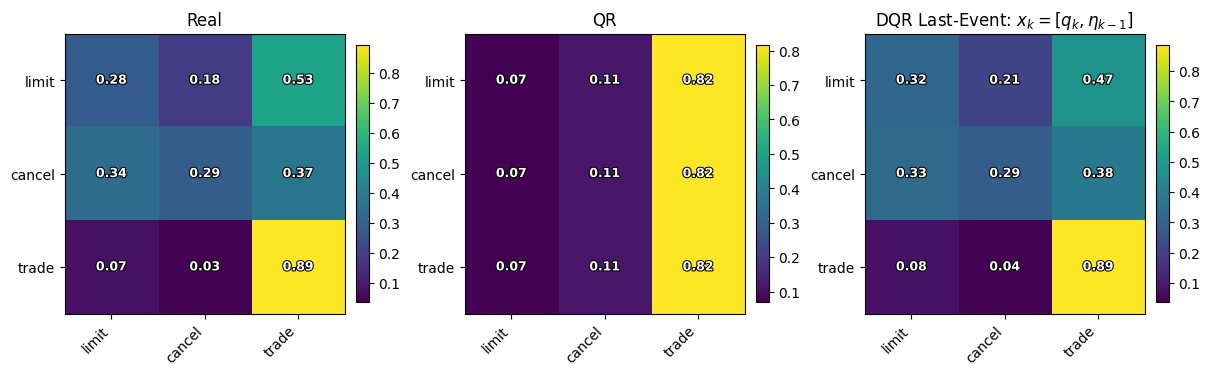

In [115]:
from dqrfunctions import plot_two_heatmaps, plot_three_heatmaps

EVENT_NAMES = ["limit", "cancel", "trade"]
dqr_last_event_title = r"DQR Last-Event: $x_k=[q_k,\eta_{k-1}]$"
dqr_hour_last_event_title = r"DQR Hour + Last-Event: $x_k=[q_k,\eta_{k-1},h_k]$"

fig = plot_three_heatmaps(T_real, T_qr, T_dqr_le, labels=EVENT_NAMES, dqr_title=dqr_last_event_title)
plt.show()

In [116]:
from dqrfunctions import compute_hourly_intensity, compute_real_hourly_intensity
hourly_dqr_h = compute_hourly_intensity(model_hour, data_hour, df_train["hour"].values)
hourly_dqr_h_le = compute_hourly_intensity(model_hour_last_event, data_hour_last_event, df_train["hour"].values)
hourly_real = compute_real_hourly_intensity(df_train, trade_id=2)
hourly_qr = 1/T_qr[:,2].mean()

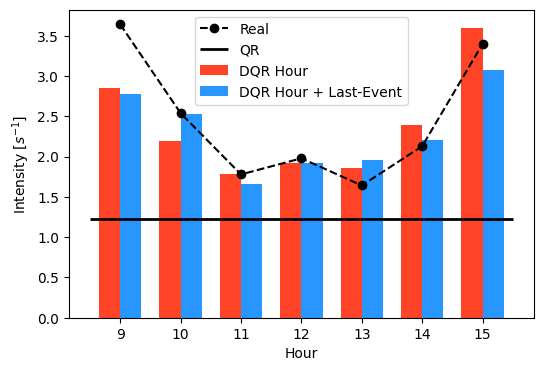

In [117]:
width = 0.35
x = hourly_dqr_h.index.values
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(x - width/2, hourly_dqr_h.values, width=width, color="#FF4327", label="DQR Hour")
ax.bar(x + width/2, hourly_dqr_h_le.values, width=width, color="#2797FF", label="DQR Hour + Last-Event")
ax.plot(x, hourly_real.values, "o--", color="black", label="Real")
ax.hlines(hourly_qr, xmin=x.min() - 0.5, xmax=x.max() + 0.5, colors="black", linestyles="-", linewidth = 2, label="QR")
ax.set_xlabel("Hour")
ax.set_ylabel(r"Intensity [$s^{-1}$]")
ax.set_xticks(x)
ax.legend()
plt.show()

# EN TRAVAUX #

In [118]:
@torch.no_grad()
def predict_lambdas(model, data, batch_size=4096):
    model.eval()
    N = data["q"].shape[0]
    out = torch.empty((N, 3), dtype=torch.float32)

    for s in range(0, N, batch_size):
        q_batch = data["q"][s:s+batch_size]

        if model.use_hour and model.use_last_event:
            hour_batch = data["hour_id"][s:s+batch_size]
            last_event_batch = data["last_event"][s:s+batch_size]
            lambdas = model(q_batch, last_event=last_event_batch, hour=hour_batch)

        elif model.use_last_event:
            last_event_batch = data["last_event"][s:s+batch_size]
            lambdas = model(q_batch, last_event=last_event_batch)

        elif model.use_hour:
            hour_batch = data["hour_id"][s:s+batch_size]
            lambdas = model(q_batch, hour=hour_batch)

        else:
            lambdas = model(q_batch)

        out[s:s+batch_size] = lambdas.cpu()

    return out.numpy()


def balanced_accuracy_numpy(y_true, y_pred, n_classes=3):
    recalls = []
    for c in range(n_classes):
        mask = (y_true == c)
        if mask.sum() == 0:
            continue
        recalls.append((y_pred[mask] == c).mean())
    return float(np.mean(recalls))


def evaluate_dqr_model(model, data, eps=1e-12):
    lambdas = predict_lambdas(model, data)                 # shape (N,3)
    y_true = data["y"].cpu().numpy()
    dt_true = data["dt"].cpu().numpy()

    Lambda = lambdas.sum(axis=1)                          # total intensity
    chosen_lambda = lambdas[np.arange(len(y_true)), y_true]

    # 1) mean log-likelihood per observation (higher is better)
    loglik = np.mean(np.log(chosen_lambda + eps) - Lambda * dt_true)

    # 2) next-event prediction
    y_pred = np.argmax(lambdas, axis=1)
    bal_acc = balanced_accuracy_numpy(y_true, y_pred, n_classes=3)

    # 3) time-to-next-event relative difference
    # inferred from the exponential waiting time mean = 1 / Lambda
    dt_pred = 1.0 / np.maximum(Lambda, eps)
    rel_diff = np.mean(np.abs(dt_pred - dt_true) / np.maximum(dt_true, eps)) * 100.0

    return {
        "loglik": float(loglik),
        "bal_acc": float(bal_acc),
        "rel_diff_pct": float(rel_diff),
    }

In [119]:
def plot_figure3(results):
    model_names = list(results.keys())
    model_colors = {
        "Vanilla": "#1f77b4",
        "Hour": "#ff7f0e",
        "Last event": "#2ca02c",
        "Hour + Last event": "#d62728",
    }
    colors= [model_colors[m] for m in model_names]

    loglik = [results[m]["loglik"] for m in model_names]
    balacc = [results[m]["bal_acc"] for m in model_names]
    reldiff = [results[m]["rel_diff_pct"] for m in model_names]

    fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)

    axes[0].bar(model_names, loglik, color=colors)
    axes[0].set_title("Log-likelihood")
    axes[0].set_ylabel("Mean log-likelihood")
    axes[0].set_xlabel("(Higher is better)")
    axes[0].grid(axis="y", alpha=0.3)

    axes[1].bar(model_names, balacc, color=colors)
    axes[1].set_title("Next event prediction\nBalanced accuracy")
    axes[1].set_ylabel("Balanced accuracy")
    axes[1].set_xlabel("(Higher is better)")
    axes[1].grid(axis="y", alpha=0.3)

    axes[2].bar(model_names, reldiff, color=colors)
    axes[2].set_title("Time to next event\n(Relative Difference (%))")
    axes[2].set_ylabel("Relative difference (%)")
    axes[2].set_xlabel("(Lower is better)")
    axes[2].grid(axis="y", alpha=0.3)

    for ax in axes:
        ax.tick_params(axis="x", rotation=20)

    plt.show()

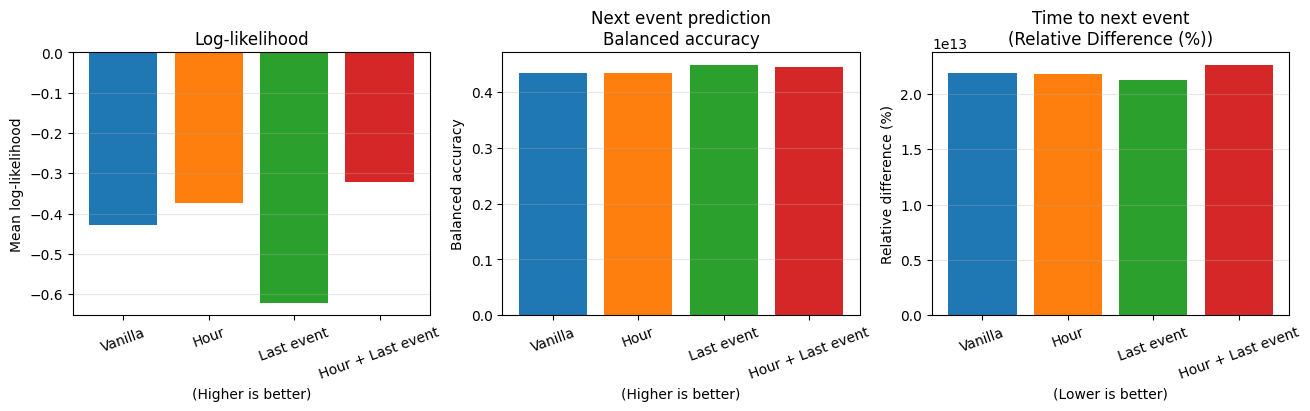

In [120]:
results = {
    "Vanilla": evaluate_dqr_model(model_vanilla, data_vanilla),
    "Hour": evaluate_dqr_model(model_hour, data_hour),
    "Last event": evaluate_dqr_model(model_last_event, data_last_event),
    "Hour + Last event": evaluate_dqr_model(model_hour_last_event, data_hour_last_event),
}

results
plot_figure3(results)

In [121]:
print(data_hour)

{'q': tensor([0., 0., 0.,  ..., 0., 0., 0.]), 'y': tensor([2, 2, 2,  ..., 2, 2, 0]), 'dt': tensor([0.0533, 0.0000, 0.0000,  ..., 0.1437, 0.1387, 0.0000]), 'hour_id': tensor([0, 0, 0,  ..., 6, 6, 6])}
